In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = sns.load_dataset('titanic')
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [5]:
df = df[['age','fare','survived']]
df.head(2)

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1


# Binning
> here we convert numerical -> categorical data
- uniform / eqaul width binning
- quantile / equal frequency binning
- K-means binning

In [6]:
from sklearn.preprocessing import KBinsDiscretizer

In [7]:
kbin_unif = KBinsDiscretizer(n_bins=9,encode='ordinal',strategy='uniform')
kbin_quan = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_kmean = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')


In [8]:
# here make sure you notice that age has missing values
from sklearn.impute import SimpleImputer
si = SimpleImputer()
df['age'] = si.fit_transform(df[['age']])

In [9]:
df['age1'] = kbin_unif.fit_transform(df[['age']])
df.age1.value_counts()

age1
3.0    355
2.0    180
4.0    102
1.0     77
5.0     65
0.0     62
6.0     35
7.0     13
8.0      2
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Count'>

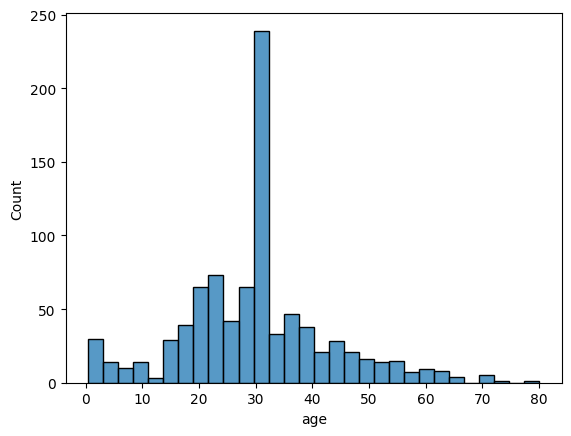

In [10]:
sns.histplot(df['age'])

<Axes: xlabel='age1', ylabel='Count'>

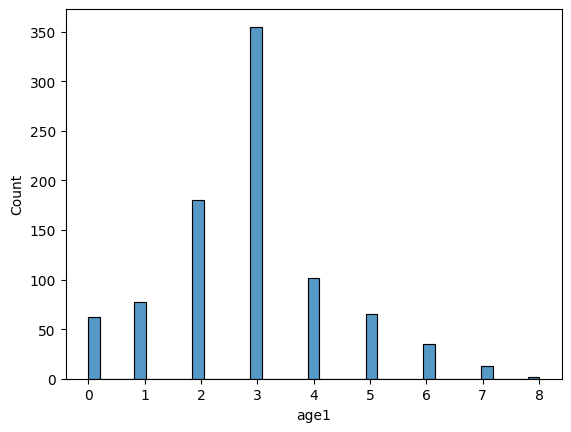

In [11]:
sns.histplot(df['age1'])

In [12]:
df['age2'] = kbin_quan.fit_transform(df[['age']])
df.age2.value_counts()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


age2
5.0    239
8.0     98
3.0     90
7.0     90
2.0     83
0.0     83
1.0     81
6.0     80
4.0     47
Name: count, dtype: int64

<Axes: xlabel='age2', ylabel='Count'>

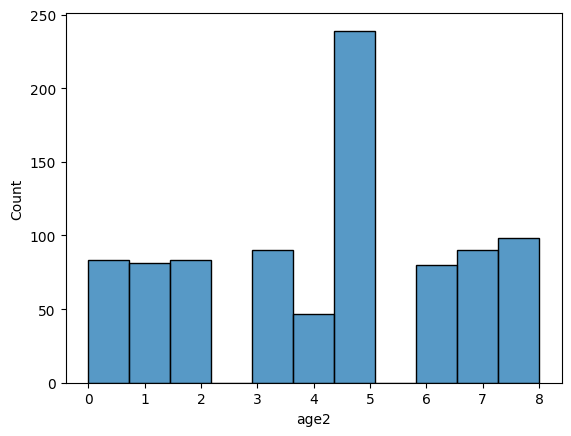

In [13]:
sns.histplot(df['age2'])

In [14]:
df['age3'] = kbin_kmean.fit_transform(df[['age']])
df.age3.value_counts()

age3
3.0    324
2.0    188
4.0    116
5.0     70
1.0     59
0.0     54
6.0     45
7.0     24
8.0      9
9.0      2
Name: count, dtype: int64

<Axes: xlabel='age3', ylabel='Count'>

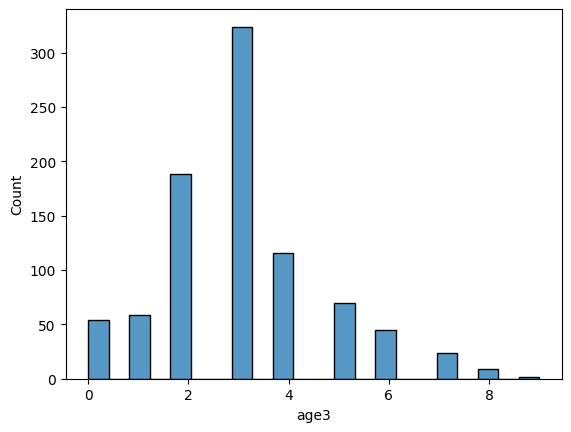

In [15]:
sns.histplot(df['age3'])